# Financial Budget & Expense Variance Analysis

**A Business Analytics Case Study on Organizational Spending Performance**

---

### Business Objective

Organizations plan annual and departmental budgets, but actual spending frequently diverges from these plans. This project analyzes a transaction-level dataset of budgeted versus actual expenditure to identify **which departments, expense categories, regions, and time periods are responsible for significant budget variances**, and to translate those findings into actionable recommendations for financial management.

### Business Questions

This notebook is structured to answer the following questions:

1. What is the total budgeted amount versus actual spending?
2. What is the overall budget variance and variance percentage?
3. Which departments are overspending relative to their budgets?
4. Which expense categories contribute most to unfavorable variance?
5. Which regions have the highest budget overruns?
6. How does spending vary over time?
7. Which department–category combinations have the largest unfavorable variances?
8. Are there periods with unusually high spending?
9. Which areas consistently exceed their budgets?
10. What business actions can management take based on the findings?


### Dataset

**Source file:** `Budget_vs_Actual_Data.xlsx`
**Records:** ~10,010 financial transactions
**Fields:** Date, Department, Category, Region, Budget Amount, Actual Amount, Payment Method, Transaction ID


## 1. Import Libraries

We import only the libraries required for this analysis: data handling (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and lightweight statistical/forecasting tools (`scipy.stats`, `sklearn.linear_model`). No unnecessary machine learning libraries are used, in line with the business-analytics (not ML) framing of this project.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

warnings.filterwarnings('ignore')

# Professional plotting configuration
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['font.size'] = 10
plt.rcParams['axes.edgecolor'] = '#4d4d4d'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PALETTE = sns.color_palette('crest', 10)
FAV_COLOR = '#2E8B57'    # favorable / green
UNFAV_COLOR = '#C0392B'  # unfavorable / red
BUDGET_COLOR = '#4C72B0'
ACTUAL_COLOR = '#DD8452'

def currency_fmt(x, pos=None):
    """Format large numbers as currency without scientific notation."""
    return f'${x:,.0f}'

pd.options.display.float_format = lambda x: f'{x:,.2f}'
print('Libraries imported and plotting environment configured.')

Libraries imported and plotting environment configured.


## 2. Load the Data

We load the raw transaction-level dataset and perform an initial inspection: shape, column names, data types, and a preview of the first and last records.

**Column definitions:**

| Column | Description |
|---|---|
| `Date` | Date the transaction was recorded |
| `Department` | Internal department responsible for the spend (e.g., Sales, IT, Finance) |
| `Category` | Expense category (e.g., Travel, Salaries, Training) |
| `Region` | Geographic region associated with the transaction |
| `Budget Amount` | Planned/budgeted amount for the transaction |
| `Actual Amount` | Actual amount spent |
| `Payment Method` | How the transaction was paid (Card, Cash, UPI, Bank Transfer) |
| `Transaction ID` | Unique identifier for the transaction |


In [ ]:
path = r"C:\Users\sreeshanth\OneDrive\Documents\FINANCIAL BUDGET EXPENSE ANALYSIS\data\Budget_vs_Actual_Data.xlsx"

df_raw = pd.read_excel(path)

print(f"Dataset shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns\n")
print("Column names:")
print(list(df_raw.columns))

Dataset shape: 10,010 rows x 8 columns

Column names:
['Date', 'Department', 'Category', 'Region', 'Budget Amount', 'Actual Amount', 'Payment Method', 'Transaction ID']


In [11]:
print("Data types:\n")
print(df_raw.dtypes)

Data types:

Date              datetime64[ns]
Department                object
Category                  object
Region                    object
Budget Amount              int64
Actual Amount              int64
Payment Method            object
Transaction ID            object
dtype: object


In [12]:
df_raw.head()

,Date,Department,Category,Region,Budget Amount,Actual Amount,Payment Method,Transaction ID
0,2023-05-11,Sales,Travel,North,126096,43048,Card,TXN100000
1,2023-11-11,Marketing,Salaries,East,19702,87896,Bank Transfer,TXN100001
2,2021-05-02,IT,Training,Central,108523,103632,Card,TXN100002
3,2022-04-12,Marketing,Salaries,North,114711,105574,Cash,TXN100003
4,2021-11-27,Sales,Utilities,Central,121895,64314,UPI,TXN100004


In [13]:
df_raw.tail()

,Date,Department,Category,Region,Budget Amount,Actual Amount,Payment Method,Transaction ID
10005,2022-04-18,Marketing,Marketing,South,23229,89695,Bank Transfer,TXN108517
10006,2021-05-12,Sales,Infrastructure,South,28919,65335,Card,TXN102041
10007,2021-08-23,Sales,Utilities,East,82957,72156,UPI,TXN101989
10008,2022-01-03,Finance,Infrastructure,North,68546,91058,Cash,TXN101933
10009,2023-01-19,Sales,Travel,Central,102272,114341,Card,TXN109984


## 3. Data Quality Assessment

Before any cleaning is performed, we assess the raw dataset's quality: missing values, duplicate records, duplicate transaction IDs, invalid or unexpected values, and outliers. **No records are modified in this section** — we only diagnose issues here and treat them in the next section, with justification for each decision.

In [14]:
quality_summary = pd.DataFrame({
    'Data Type': df_raw.dtypes.astype(str),
    'Missing Count': df_raw.isna().sum(),
    'Missing %': (df_raw.isna().mean() * 100).round(2),
    'Unique Values': df_raw.nunique()
})
quality_summary

,Data Type,Missing Count,Missing %,Unique Values
Date,datetime64[ns],0,0.00,1095
Department,object,1,0.01,6
Category,object,1,0.01,6
Region,object,3,0.03,5
Budget Amount,int64,0,0.00,9638
Actual Amount,int64,0,0.00,9703
Payment Method,object,0,0.00,4
Transaction ID,object,3,0.03,9997


In [15]:
# Duplicate rows (fully identical across all columns)
full_duplicates = df_raw.duplicated().sum()
print(f"Fully duplicated rows: {full_duplicates}")

# Duplicate Transaction IDs (excluding missing IDs, which are examined separately)
txn_id_present = df_raw[df_raw['Transaction ID'].notna()]
dup_txn_ids = txn_id_present['Transaction ID'].duplicated().sum()
print(f"Duplicate Transaction IDs (excluding missing IDs): {dup_txn_ids}")
print(f"Missing Transaction IDs: {df_raw['Transaction ID'].isna().sum()}")

Fully duplicated rows: 10
Duplicate Transaction IDs (excluding missing IDs): 10
Missing Transaction IDs: 3


In [17]:
# Inspect the duplicate Transaction ID records directly
dup_id_mask = txn_id_present['Transaction ID'].duplicated(keep=False)
duplicate_txn_records = txn_id_present[dup_id_mask].sort_values('Transaction ID')
print(f"Rows involved in duplicate Transaction IDs: {len(duplicate_txn_records)}")
duplicate_txn_records.head(12)

Rows involved in duplicate Transaction IDs: 20


,Date,Department,Category,Region,Budget Amount,Actual Amount,Payment Method,Transaction ID
1933,2022-01-03,Finance,Infrastructure,North,68546,91058,Cash,TXN101933
10008,2022-01-03,Finance,Infrastructure,North,68546,91058,Cash,TXN101933
10007,2021-08-23,Sales,Utilities,East,82957,72156,UPI,TXN101989
1989,2021-08-23,Sales,Utilities,East,82957,72156,UPI,TXN101989
10006,2021-05-12,Sales,Infrastructure,South,28919,65335,Card,TXN102041
2041,2021-05-12,Sales,Infrastructure,South,28919,65335,Card,TXN102041
3850,2021-11-24,Marketing,Utilities,South,69911,157260,Cash,TXN103850
10001,2021-11-24,Marketing,Utilities,South,69911,157260,Cash,TXN103850
3886,2023-10-14,Marketing,Salaries,East,30855,36986,Card,TXN103886
10003,2023-10-14,Marketing,Salaries,East,30855,36986,Card,TXN103886


In [ ]:
# Check whether duplicate-ID rows are also fully duplicate rows (same values across ALL columns)
fully_dup_rows = df_raw[df_raw.duplicated(keep=False)]
are_all_dup_ids_full_duplicates = set(duplicate_txn_records.index).issubset(set(fully_dup_rows.index)) \
    and len(duplicate_txn_records) == len(fully_dup_rows)
print(f"Rows with duplicate Transaction IDs: {len(duplicate_txn_records)}")
print(f"Fully duplicated rows (all columns identical): {len(fully_dup_rows)}")
print(f"Are the duplicate-ID rows exact full-row duplicates? {are_all_dup_ids_full_duplicates}")

Rows with duplicate Transaction IDs: 20
Fully duplicated rows (all columns identical): 20
Are the duplicate-ID rows exact full-row duplicates? True


In [ ]:
# Check numeric validity: negative or zero budget/actual values
neg_budget = (df_raw['Budget Amount'] < 0).sum()
neg_actual = (df_raw['Actual Amount'] < 0).sum()
zero_budget = (df_raw['Budget Amount'] == 0).sum()
zero_actual = (df_raw['Actual Amount'] == 0).sum()

print(f"Negative Budget Amount values: {neg_budget}")
print(f"Negative Actual Amount values: {neg_actual}")
print(f"Zero Budget Amount values: {zero_budget}")
print(f"Zero Actual Amount values: {zero_actual}")

Negative Budget Amount values: 0
Negative Actual Amount values: 0
Zero Budget Amount values: 0
Zero Actual Amount values: 0


In [ ]:
# Check date validity
invalid_dates = df_raw['Date'].isna().sum()
print(f"Missing/invalid dates: {invalid_dates}")
print(f"Date range: {df_raw['Date'].min().date()} to {df_raw['Date'].max().date()}")

Missing/invalid dates: 0
Date range: 2021-01-01 to 2023-12-31


In [ ]:
# Check categorical values for unexpected entries
for col in ['Department', 'Category', 'Region', 'Payment Method']:
    print(f"\n{col} — unique values ({df_raw[col].nunique()} distinct, {df_raw[col].isna().sum()} missing):")
    print(sorted(df_raw[col].dropna().unique().tolist()))


Department — unique values (6 distinct, 1 missing):
['Finance', 'HR', 'IT', 'Marketing', 'Operations', 'Sales']

Category — unique values (6 distinct, 1 missing):
['Infrastructure', 'Marketing', 'Salaries', 'Training', 'Travel', 'Utilities']

Region — unique values (5 distinct, 3 missing):
['Central', 'East', 'North', 'South', 'West']

Payment Method — unique values (4 distinct, 0 missing):
['Bank Transfer', 'Card', 'Cash', 'UPI']


In [ ]:
# Outlier scan (IQR method) on Budget Amount and Actual Amount — diagnostic only, no removal yet
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum(), lower, upper

for col in ['Budget Amount', 'Actual Amount']:
    n_out, lo, hi = iqr_outlier_count(df_raw[col])
    print(f"{col}: {n_out} potential outliers outside [{lo:,.0f}, {hi:,.0f}] (IQR method)")

Budget Amount: 0 potential outliers outside [-60,915, 219,870] (IQR method)
Actual Amount: 0 potential outliers outside [-74,453, 253,610] (IQR method)


**Findings summary:**

- Small amounts of missing data exist in `Department`, `Category`, `Region`, and `Transaction ID` (a handful of records each — well under 0.1% of the dataset).
- There are fully duplicated rows in the dataset, and they correspond exactly to the records with duplicate Transaction IDs — i.e., these are true duplicate transactions (the entire row was recorded twice), not two different transactions that happen to share an ID.
- No negative or zero values exist in `Budget Amount` or `Actual Amount`, and no invalid dates were found.
- No unexpected categories appear in `Department`, `Category`, `Region`, or `Payment Method` beyond missing values.
- The IQR method flags a modest number of high-value transactions in both `Budget Amount` and `Actual Amount` as statistical outliers; these are examined in detail in the dedicated Outlier Analysis section rather than removed here.

These findings are addressed with justified treatments in the Data Cleaning section below.

## 4. Data Cleaning

Each cleaning step below is applied **only where justified by the findings above**, and the reasoning is stated explicitly.

In [ ]:
df = df_raw.copy()
shape_before = df.shape
print(f"Shape before cleaning: {shape_before}")

Shape before cleaning: (10010, 8)


**Step 1 — Remove true duplicate rows.**
The data quality check showed that duplicated Transaction IDs correspond to fully duplicated rows (identical values in every column). These represent the same transaction recorded twice, most likely due to a data entry or export error, and keeping them would double-count spending. We drop the repeated occurrences, keeping the first instance of each.

In [ ]:
before = len(df)
df = df.drop_duplicates(keep='first')
after = len(df)
print(f"Removed {before - after} exact duplicate row(s). Rows: {before} -> {after}")

Removed 10 exact duplicate row(s). Rows: 10010 -> 10000


In [ ]:
df.to_csv("Budget_vs_Actual_Data.csv", index=False)

**Step 2 — Handle missing categorical values (`Department`, `Category`, `Region`).**
Each of these fields is missing in only a handful of records. Because a missing dimension value cannot be reliably inferred (there is no reasonable rule to assign a transaction to a specific department, category, or region), and because the number of affected rows is negligible relative to the 10,000+ record dataset, we label them explicitly as `"Unknown"` rather than dropping the rows outright. This preserves the transactions' Budget/Actual amounts for aggregate KPI calculations while keeping them clearly separated from the dimension-level dataset so that department/category/region-level analysis is not distorted by mislabeled data.

In [ ]:
for col in ['Department', 'Category', 'Region']:
    missing_before = df[col].isna().sum()
    df[col] = df[col].fillna('Unknown')
    print(f"{col}: filled {missing_before} missing value(s) with 'Unknown'")

Department: filled 1 missing value(s) with 'Unknown'
Category: filled 1 missing value(s) with 'Unknown'
Region: filled 3 missing value(s) with 'Unknown'


**Step 3 — Handle missing `Transaction ID`.**
A small number of transactions lack an ID. Since `Transaction ID` is only used for record-level identification (not for any aggregation or grouping), we assign a placeholder ID so the field remains usable for lookups, rather than dropping otherwise valid financial records.

In [ ]:
missing_id_mask = df['Transaction ID'].isna()
n_missing_ids = missing_id_mask.sum()
df.loc[missing_id_mask, 'Transaction ID'] = [f'TXN_UNKNOWN_{i:03d}' for i in range(n_missing_ids)]
print(f"Assigned placeholder IDs to {n_missing_ids} record(s) with missing Transaction ID")

Assigned placeholder IDs to 3 record(s) with missing Transaction ID


**Step 4 — Validate numeric and date columns.**
`Budget Amount` and `Actual Amount` are confirmed as numeric (no negative or zero values were found, so no correction is required), and `Date` is already stored as a proper datetime type with no missing values. We explicitly enforce these types below to guarantee downstream calculations behave correctly.

In [ ]:
df['Budget Amount'] = pd.to_numeric(df['Budget Amount'], errors='coerce')
df['Actual Amount'] = pd.to_numeric(df['Actual Amount'], errors='coerce')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Confirm the enforcement introduced no new missing values
print("Post-validation missing values:")
print(df[['Date', 'Budget Amount', 'Actual Amount']].isna().sum())

Post-validation missing values:
Date             0
Budget Amount    0
Actual Amount    0
dtype: int64


In [ ]:
shape_after = df.shape
print(f"Shape before cleaning: {shape_before}")
print(f"Shape after cleaning:  {shape_after}")
print(f"Net rows removed: {shape_before[0] - shape_after[0]}")

Shape before cleaning: (10010, 8)
Shape after cleaning:  (10000, 8)
Net rows removed: 10


## 5. Feature Engineering

We derive a small set of metrics directly from the existing columns — every derived column below is a legitimate calculation from `Budget Amount`, `Actual Amount`, or `Date`. No external or fabricated fields (e.g., profit, cost, vendor) are introduced.

| Derived Column | Formula | Business Meaning |
|---|---|---|
| `Variance` | Actual − Budget | Dollar amount by which spending missed (−) or exceeded (+) the budget |
| `Variance %` | Variance / Budget × 100 | Variance scaled relative to the size of the budget, enabling fair comparison across transactions of different sizes |
| `Budget Utilization %` | Actual / Budget × 100 | Share of the budget consumed; 100% = spent exactly to plan |
| `Variance Status` | Sign of Variance | Categorizes each transaction as Favorable, Unfavorable, or On Budget |
| `Year`, `Quarter`, `Month`, `Month Number`, `Year-Month` | Extracted from `Date` | Enable time-based aggregation and trend analysis |


In [ ]:
# Variance and Variance %  (division by zero safely handled — no zero budgets exist, but guarded regardless)
df['Variance'] = df['Actual Amount'] - df['Budget Amount']
df['Variance %'] = np.where(
    df['Budget Amount'] != 0,
    (df['Variance'] / df['Budget Amount']) * 100,
    np.nan
)

# Budget Utilization %
df['Budget Utilization %'] = np.where(
    df['Budget Amount'] != 0,
    (df['Actual Amount'] / df['Budget Amount']) * 100,
    np.nan
)

# Variance Status
df['Variance Status'] = np.select(
    [df['Variance'] > 0, df['Variance'] < 0],
    ['Unfavorable', 'Favorable'],
    default='On Budget'
)

# Time-based features
df['Year'] = df['Date'].dt.year
df['Quarter'] = df['Date'].dt.quarter
df['Month Number'] = df['Date'].dt.month
df['Month'] = df['Date'].dt.strftime('%b')
df['Year-Month'] = df['Date'].dt.to_period('M').astype(str)

print("Derived columns created:")
print([c for c in df.columns if c not in df_raw.columns])
df[['Budget Amount', 'Actual Amount', 'Variance', 'Variance %', 'Budget Utilization %', 'Variance Status']].head()

Derived columns created:
['Variance', 'Variance %', 'Budget Utilization %', 'Variance Status', 'Year', 'Quarter', 'Month Number', 'Month', 'Year-Month']


,Budget Amount,Actual Amount,Variance,Variance %,Budget Utilization %,Variance Status
0,126096,43048,-83048,-65.86,34.14,Favorable
1,19702,87896,68194,346.13,446.13,Unfavorable
2,108523,103632,-4891,-4.51,95.49,Favorable
3,114711,105574,-9137,-7.97,92.03,Favorable
4,121895,64314,-57581,-47.24,52.76,Favorable


## 6. Executive KPI Summary

High-level KPIs that frame the rest of the analysis.

In [ ]:
total_budget = df['Budget Amount'].sum()
total_actual = df['Actual Amount'].sum()
total_variance = total_actual - total_budget
overall_variance_pct = (total_variance / total_budget) * 100
overall_utilization_pct = (total_actual / total_budget) * 100

n_transactions = len(df)
n_departments = df.loc[df['Department'] != 'Unknown', 'Department'].nunique()
n_categories = df.loc[df['Category'] != 'Unknown', 'Category'].nunique()
n_regions = df.loc[df['Region'] != 'Unknown', 'Region'].nunique()

kpi_table = pd.DataFrame({
    'KPI': [
        'Total Budget', 'Total Actual Spending', 'Total Variance ($)', 'Overall Variance (%)',
        'Overall Budget Utilization (%)', 'Number of Transactions', 'Number of Departments',
        'Number of Categories', 'Number of Regions'
    ],
    'Value': [
        f"${total_budget:,.0f}", f"${total_actual:,.0f}", f"${total_variance:,.0f}",
        f"{overall_variance_pct:.2f}%", f"{overall_utilization_pct:.2f}%",
        f"{n_transactions:,}", n_departments, n_categories, n_regions
    ]
})
kpi_table

,KPI,Value
0,Total Budget,"$795,469,256"
1,Total Actual Spending,"$890,267,029"
2,Total Variance ($),"$94,797,773"
3,Overall Variance (%),11.92%
4,Overall Budget Utilization (%),111.92%
5,Number of Transactions,"10,000"
6,Number of Departments,6
7,Number of Categories,6
8,Number of Regions,5


In [ ]:
status = "OVER budget" if overall_variance_pct > 0.5 else ("UNDER budget" if overall_variance_pct < -0.5 else "ON budget")
print(f"Overall, actual spending of ${total_actual:,.0f} against a budget of ${total_budget:,.0f}")
print(f"results in the organization running {status}, with a total variance of ${total_variance:,.0f} ({overall_variance_pct:.2f}%).")

Overall, actual spending of $890,267,029 against a budget of $795,469,256
results in the organization running OVER budget, with a total variance of $94,797,773 (11.92%).


## 7. Overall Budget vs. Actual Analysis

We compare total budgeted vs. actual spending, then break down how many transactions individually landed over vs. under budget.

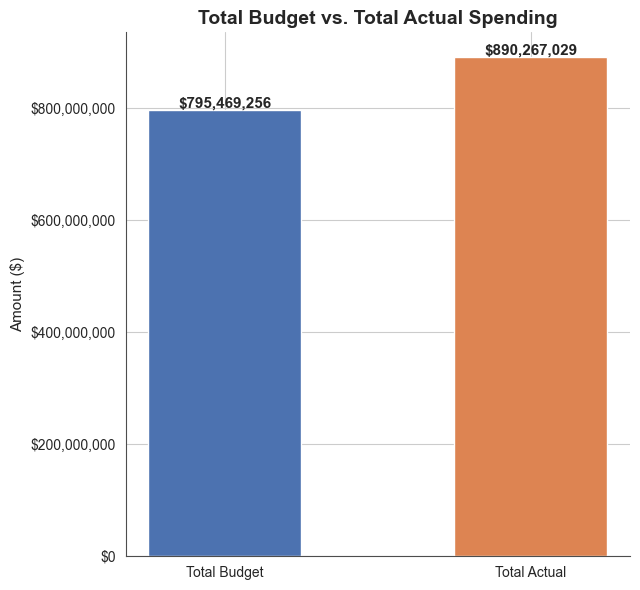

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 6))
bars = ax.bar(['Total Budget', 'Total Actual'], [total_budget, total_actual],
              color=[BUDGET_COLOR, ACTUAL_COLOR], width=0.5)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f'${b.get_height():,.0f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Total Budget vs. Total Actual Spending')
ax.set_ylabel('Amount ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(currency_fmt))
plt.tight_layout()
plt.show()

In [ ]:
favorable_amount = df.loc[df['Variance'] < 0, 'Variance'].sum()
unfavorable_amount = df.loc[df['Variance'] > 0, 'Variance'].sum()

pct_over_budget = (df['Variance'] > 0).mean() * 100
pct_under_budget = (df['Variance'] < 0).mean() * 100
pct_on_budget = (df['Variance'] == 0).mean() * 100

print(f"Favorable variance (spent less than budgeted): ${favorable_amount:,.0f}")
print(f"Unfavorable variance (spent more than budgeted): ${unfavorable_amount:,.0f}")
print(f"\nTransactions over budget:  {pct_over_budget:.2f}%")
print(f"Transactions under budget: {pct_under_budget:.2f}%")
print(f"Transactions exactly on budget: {pct_on_budget:.2f}%")

Favorable variance (spent less than budgeted): $-207,553,974
Unfavorable variance (spent more than budgeted): $302,351,747

Transactions over budget:  55.90%
Transactions under budget: 44.10%
Transactions exactly on budget: 0.00%


**Interpretation:** The chart above shows the total planned vs. actual spend at the organizational level, while the transaction-level split shows that overspending is not a rare event — a substantial share of individual transactions exceed their budgeted amount, even where the totals may appear close. This is the starting point for narrowing down *where* the unfavorable variance concentrates in the sections that follow.

## 8. Department Analysis

We aggregate Budget vs. Actual spending by `Department` to identify which departments are overspending and by how much.

In [ ]:
dept_summary = df.groupby('Department').agg(
    Total_Budget=('Budget Amount', 'sum'),
    Total_Actual=('Actual Amount', 'sum'),
    Transaction_Count=('Transaction ID', 'count')
).reset_index()
dept_summary['Variance'] = dept_summary['Total_Actual'] - dept_summary['Total_Budget']
dept_summary['Variance %'] = (dept_summary['Variance'] / dept_summary['Total_Budget']) * 100
dept_summary['Budget Utilization %'] = (dept_summary['Total_Actual'] / dept_summary['Total_Budget']) * 100
dept_summary = dept_summary.sort_values('Variance', ascending=False).reset_index(drop=True)
dept_summary.rename(columns={'Total_Budget': 'Total Budget', 'Total_Actual': 'Total Actual',
                              'Transaction_Count': 'Transaction Count'}, inplace=True)
dept_summary

,Department,Total Budget,Total Actual,Transaction Count,Variance,Variance %,Budget Utilization %
0,Marketing,131939479,151816098,1696,19876619,15.06,115.06
1,HR,137371163,155439763,1727,18068600,13.15,113.15
2,Sales,134702488,151344999,1685,16642511,12.36,112.36
3,Operations,132622213,147803987,1649,15181774,11.45,111.45
4,IT,125771001,139663026,1589,13892025,11.05,111.05
5,Finance,132947149,144084529,1653,11137380,8.38,108.38
6,Unknown,115763,114627,1,-1136,-0.98,99.02


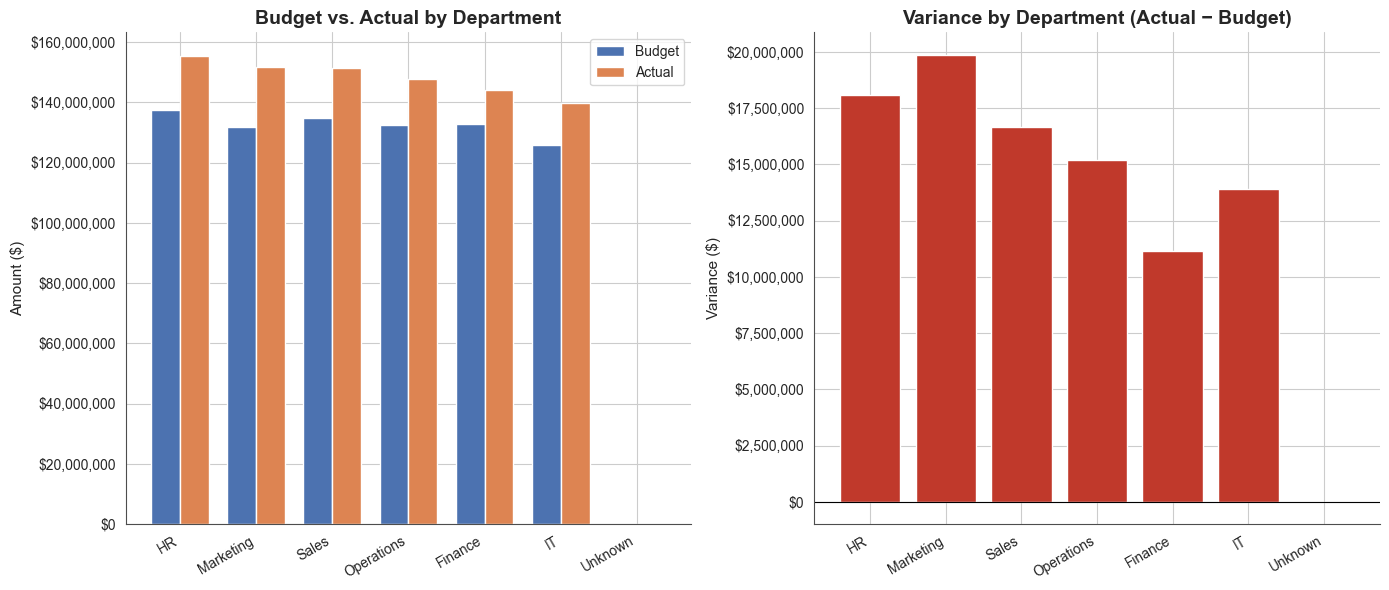

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

order = dept_summary.sort_values('Total Actual', ascending=False)['Department']
plot_df = dept_summary.set_index('Department').loc[order].reset_index()

x = np.arange(len(plot_df))
width = 0.38
axes[0].bar(x - width/2, plot_df['Total Budget'], width, label='Budget', color=BUDGET_COLOR)
axes[0].bar(x + width/2, plot_df['Total Actual'], width, label='Actual', color=ACTUAL_COLOR)
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_df['Department'], rotation=30, ha='right')
axes[0].set_title('Budget vs. Actual by Department')
axes[0].set_ylabel('Amount ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(currency_fmt))
axes[0].legend()

colors = [UNFAV_COLOR if v > 0 else FAV_COLOR for v in plot_df['Variance']]
axes[1].bar(plot_df['Department'], plot_df['Variance'], color=colors)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Variance by Department (Actual − Budget)')
axes[1].set_ylabel('Variance ($)')
axes[1].set_xticklabels(plot_df['Department'], rotation=30, ha='right')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(currency_fmt))

plt.tight_layout()
plt.show()

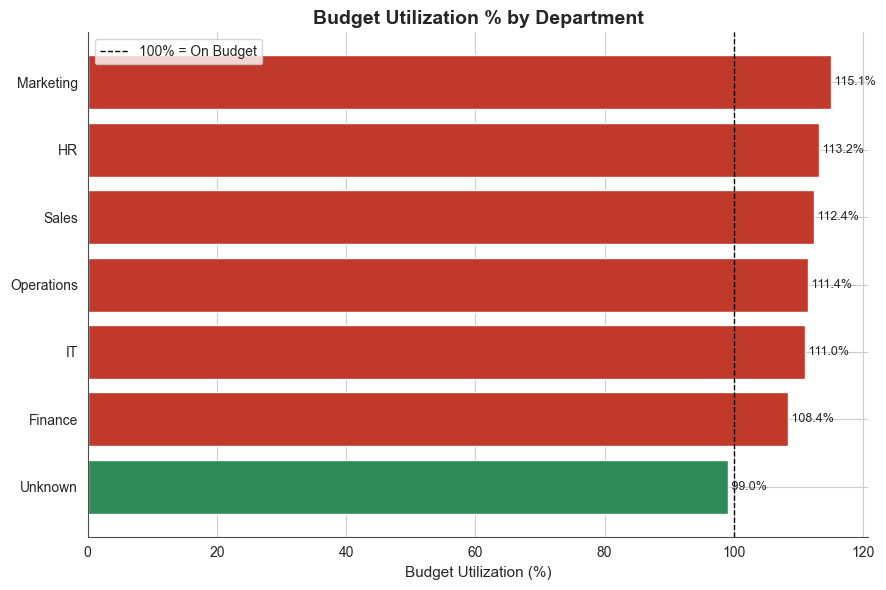

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
util_sorted = dept_summary.sort_values('Budget Utilization %', ascending=True)
bars = ax.barh(util_sorted['Department'], util_sorted['Budget Utilization %'],
               color=[UNFAV_COLOR if v > 100 else FAV_COLOR for v in util_sorted['Budget Utilization %']])
ax.axvline(100, color='black', linestyle='--', linewidth=1, label='100% = On Budget')
ax.set_title('Budget Utilization % by Department')
ax.set_xlabel('Budget Utilization (%)')
ax.legend()
for bar, val in zip(bars, util_sorted['Budget Utilization %']):
    ax.text(val, bar.get_y() + bar.get_height()/2, f' {val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
top_over_dept = dept_summary.iloc[0]
top_fav_dept = dept_summary.sort_values('Variance').iloc[0]
top_util_dept = dept_summary.sort_values('Budget Utilization %', ascending=False).iloc[0]

print(f"Highest overspending department: {top_over_dept['Department']} "
      f"(Variance: ${top_over_dept['Variance']:,.0f}, {top_over_dept['Variance %']:.2f}%)")
print(f"Largest favorable-variance department: {top_fav_dept['Department']} "
      f"(Variance: ${top_fav_dept['Variance']:,.0f}, {top_fav_dept['Variance %']:.2f}%)")
print(f"Highest budget utilization department: {top_util_dept['Department']} "
      f"({top_util_dept['Budget Utilization %']:.2f}%)")

Highest overspending department: Marketing (Variance: $19,876,619, 15.06%)
Largest favorable-variance department: Unknown (Variance: $-1,136, -0.98%)
Highest budget utilization department: Marketing (115.06%)


**Business significance:** A department with a large positive variance and utilization consistently above 100% is drawing down more resources than it was allocated, which — if repeated period over period — represents a structural budgeting gap rather than a one-off event. Conversely, a department running notably under 100% utilization may either be operating efficiently or may signal under-execution against planned initiatives; this distinction is explored further in the Consistency Analysis section.

## 9. Expense Category Analysis

We repeat the same structure at the `Category` level to identify which types of expense drive unfavorable variance.

In [ ]:
cat_summary = df.groupby('Category').agg(
    Total_Budget=('Budget Amount', 'sum'),
    Total_Actual=('Actual Amount', 'sum'),
    Transaction_Count=('Transaction ID', 'count')
).reset_index()
cat_summary['Variance'] = cat_summary['Total_Actual'] - cat_summary['Total_Budget']
cat_summary['Variance %'] = (cat_summary['Variance'] / cat_summary['Total_Budget']) * 100
cat_summary['Budget Utilization %'] = (cat_summary['Total_Actual'] / cat_summary['Total_Budget']) * 100
cat_summary = cat_summary.sort_values('Variance', ascending=False).reset_index(drop=True)
cat_summary.rename(columns={'Total_Budget': 'Budget', 'Total_Actual': 'Actual',
                             'Transaction_Count': 'Transaction Count'}, inplace=True)
cat_summary

,Category,Budget,Actual,Transaction Count,Variance,Variance %,Budget Utilization %
0,Salaries,127131160,147744247,1632,20613087,16.21,116.21
1,Utilities,137891618,155260320,1743,17368702,12.60,112.60
2,Marketing,130224132,146525696,1622,16301564,12.52,112.52
3,Travel,139968858,154885333,1742,14916475,10.66,110.66
4,Infrastructure,127813870,140825422,1623,13011552,10.18,110.18
5,Training,132399473,145010926,1637,12611453,9.53,109.53
6,Unknown,40145,15085,1,-25060,-62.42,37.58


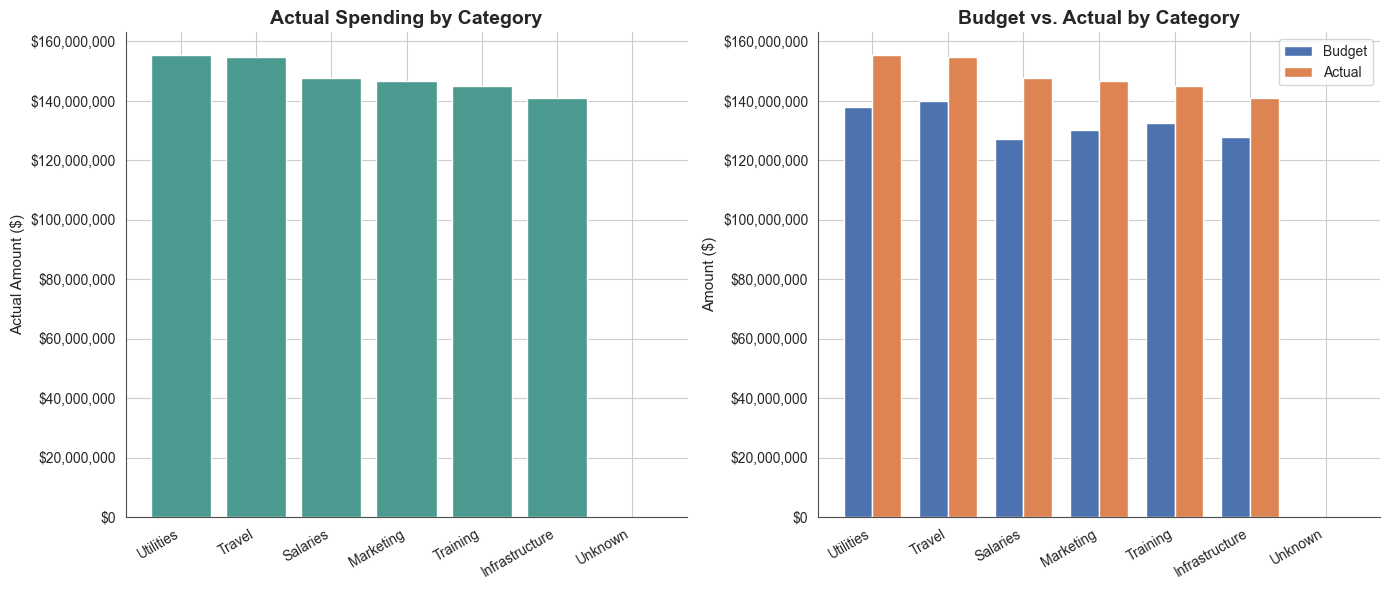

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cat_by_actual = cat_summary.sort_values('Actual', ascending=False)
axes[0].bar(cat_by_actual['Category'], cat_by_actual['Actual'], color=PALETTE[3])
axes[0].set_title('Actual Spending by Category')
axes[0].set_ylabel('Actual Amount ($)')
axes[0].set_xticklabels(cat_by_actual['Category'], rotation=30, ha='right')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(currency_fmt))

x = np.arange(len(cat_by_actual))
width = 0.38
axes[1].bar(x - width/2, cat_by_actual['Budget'], width, label='Budget', color=BUDGET_COLOR)
axes[1].bar(x + width/2, cat_by_actual['Actual'], width, label='Actual', color=ACTUAL_COLOR)
axes[1].set_xticks(x)
axes[1].set_xticklabels(cat_by_actual['Category'], rotation=30, ha='right')
axes[1].set_title('Budget vs. Actual by Category')
axes[1].set_ylabel('Amount ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(currency_fmt))
axes[1].legend()

plt.tight_layout()
plt.show()

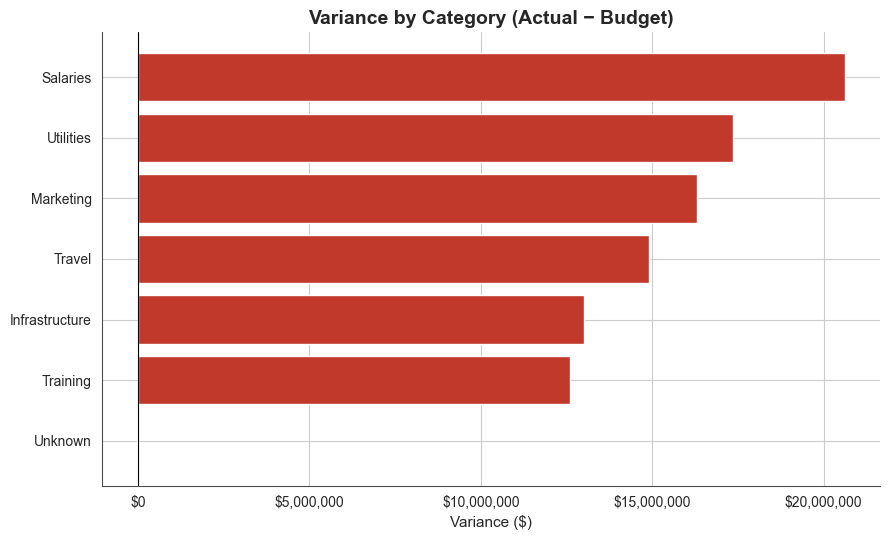

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))
cat_var_sorted = cat_summary.sort_values('Variance', ascending=True)
colors = [UNFAV_COLOR if v > 0 else FAV_COLOR for v in cat_var_sorted['Variance']]
ax.barh(cat_var_sorted['Category'], cat_var_sorted['Variance'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Variance by Category (Actual − Budget)')
ax.set_xlabel('Variance ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(currency_fmt))
plt.tight_layout()
plt.show()

In [ ]:
# Contribution of each category to total UNFAVORABLE variance only
unfav_only = df[df['Variance'] > 0]
cat_unfav_contribution = unfav_only.groupby('Category')['Variance'].sum().sort_values(ascending=False)
cat_unfav_contribution_pct = (cat_unfav_contribution / cat_unfav_contribution.sum() * 100).round(2)

contribution_table = pd.DataFrame({
    'Unfavorable Variance ($)': cat_unfav_contribution,
    'Share of Total Unfavorable Variance (%)': cat_unfav_contribution_pct
})
contribution_table

,Unfavorable Variance ($),Share of Total Unfavorable Variance (%)
Category,,
Utilities,52941544,17.51
Salaries,52753345,17.45
Travel,52513908,17.37
Marketing,48945964,16.19
Infrastructure,47685830,15.77
Training,47511156,15.71


In [ ]:
top_unfav_cat = contribution_table.index[0]
top_unfav_cat_share = contribution_table.iloc[0]['Share of Total Unfavorable Variance (%)']
print(f"'{top_unfav_cat}' is the single largest contributor to unfavorable variance, "
      f"accounting for {top_unfav_cat_share:.2f}% of all overspending across the organization.")

'Utilities' is the single largest contributor to unfavorable variance, accounting for 17.51% of all overspending across the organization.


**Findings:** Comparing budget vs. actual across categories highlights which *types* of spending — rather than which departments — are the primary drivers of cost overruns. Because the same category can be overspent across many departments, this view complements (not replaces) the department-level analysis and is essential for setting category-specific spending controls.

## 10. Regional Analysis

We analyze spending by `Region` to identify geographic concentrations of budget overruns.

In [ ]:
region_summary = df.groupby('Region').agg(
    Total_Budget=('Budget Amount', 'sum'),
    Total_Actual=('Actual Amount', 'sum'),
    Transaction_Count=('Transaction ID', 'count')
).reset_index()
region_summary['Variance'] = region_summary['Total_Actual'] - region_summary['Total_Budget']
region_summary['Variance %'] = (region_summary['Variance'] / region_summary['Total_Budget']) * 100
region_summary['Budget Utilization %'] = (region_summary['Total_Actual'] / region_summary['Total_Budget']) * 100
region_summary = region_summary.sort_values('Variance', ascending=False).reset_index(drop=True)
region_summary.rename(columns={'Total_Budget': 'Budget', 'Total_Actual': 'Actual',
                                'Transaction_Count': 'Transaction Count'}, inplace=True)
region_summary

,Region,Budget,Actual,Transaction Count,Variance,Variance %,Budget Utilization %
0,East,159685797,181076974,2038,21391177,13.40,113.40
1,Central,162657334,182078152,2044,19420818,11.94,111.94
2,South,157991439,176760699,1996,18769260,11.88,111.88
3,West,157004504,175505843,1971,18501339,11.78,111.78
4,North,157929548,174461702,1948,16532154,10.47,110.47
5,Unknown,200634,383659,3,183025,91.22,191.22


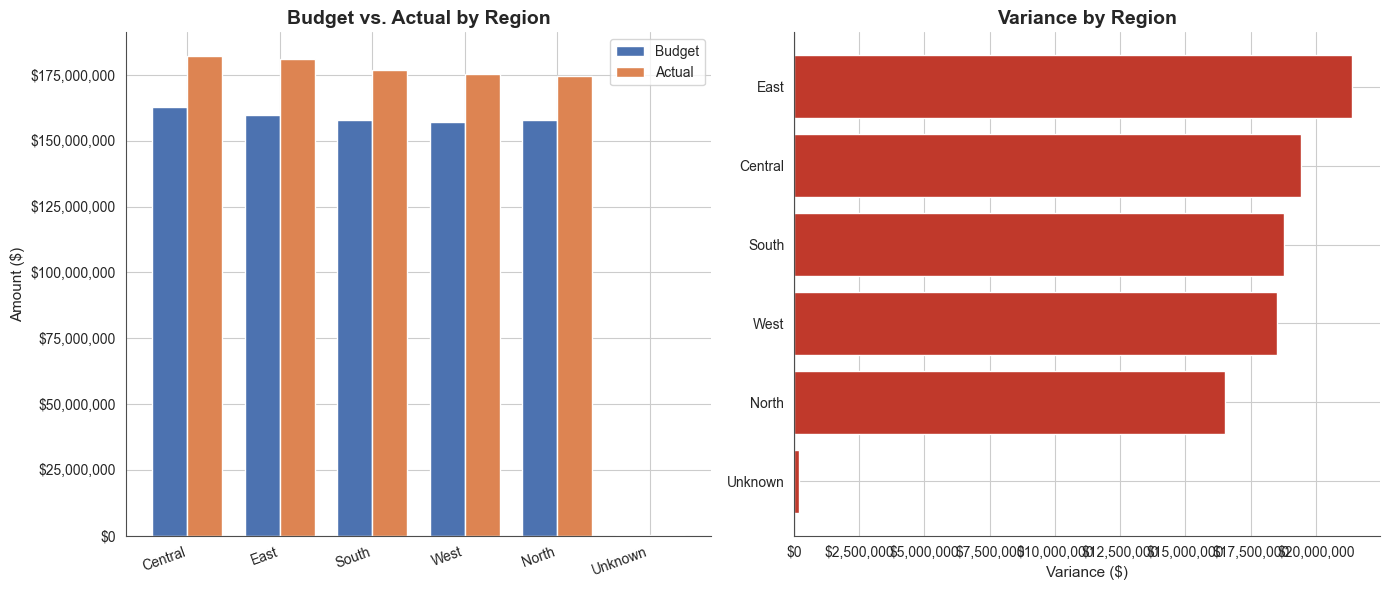

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

reg_sorted = region_summary.sort_values('Actual', ascending=False)
x = np.arange(len(reg_sorted))
width = 0.38
axes[0].bar(x - width/2, reg_sorted['Budget'], width, label='Budget', color=BUDGET_COLOR)
axes[0].bar(x + width/2, reg_sorted['Actual'], width, label='Actual', color=ACTUAL_COLOR)
axes[0].set_xticks(x)
axes[0].set_xticklabels(reg_sorted['Region'], rotation=20, ha='right')
axes[0].set_title('Budget vs. Actual by Region')
axes[0].set_ylabel('Amount ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(currency_fmt))
axes[0].legend()

reg_var_sorted = region_summary.sort_values('Variance', ascending=True)
colors = [UNFAV_COLOR if v > 0 else FAV_COLOR for v in reg_var_sorted['Variance']]
axes[1].barh(reg_var_sorted['Region'], reg_var_sorted['Variance'], color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Variance by Region')
axes[1].set_xlabel('Variance ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(currency_fmt))

plt.tight_layout()
plt.show()

In [ ]:
top_over_region = region_summary.iloc[0]
lowest_spend_region = region_summary.sort_values('Budget Utilization %').iloc[0]
top_util_region = region_summary.sort_values('Budget Utilization %', ascending=False).iloc[0]

print(f"Highest overspending region: {top_over_region['Region']} "
      f"(Variance: ${top_over_region['Variance']:,.0f}, {top_over_region['Variance %']:.2f}%)")
print(f"Lowest spending relative to budget: {lowest_spend_region['Region']} "
      f"({lowest_spend_region['Budget Utilization %']:.2f}% utilization)")
print(f"Highest budget utilization region: {top_util_region['Region']} "
      f"({top_util_region['Budget Utilization %']:.2f}% utilization)")

Highest overspending region: East (Variance: $21,391,177, 13.40%)
Lowest spending relative to budget: North (110.47% utilization)
Highest budget utilization region: Unknown (191.22% utilization)


**Business implications:** Regional variance differences may reflect a range of underlying causes — local cost-of-living differences, regional headcount, vendor pricing, or inconsistent budget-setting practices across regions. The data alone cannot confirm the specific cause, so this finding should be treated as a prompt for regional finance leads to investigate further, rather than a definitive explanation.

## 11. Time-Series Analysis

We aggregate spending by month to observe trends, spikes, and periods of favorable/unfavorable variance over the ~3-year data history, then roll up to quarterly and yearly views.

In [ ]:
monthly = df.groupby(df['Date'].dt.to_period('M')).agg(
    Budget=('Budget Amount', 'sum'),
    Actual=('Actual Amount', 'sum')
)
monthly.index = monthly.index.to_timestamp()
monthly['Variance'] = monthly['Actual'] - monthly['Budget']
monthly['Variance %'] = (monthly['Variance'] / monthly['Budget']) * 100
monthly = monthly.reset_index().rename(columns={'Date': 'Month'})
print(f"Monthly periods available: {len(monthly)}")
monthly.head()

Monthly periods available: 36


,Month,Budget,Actual,Variance,Variance %
0,2021-01-01,21587408,24913213,3325805,15.41
1,2021-02-01,18142623,20632263,2489640,13.72
2,2021-03-01,19747700,24295909,4548209,23.03
3,2021-04-01,19710246,24364104,4653858,23.61
4,2021-05-01,24597175,27250381,2653206,10.79


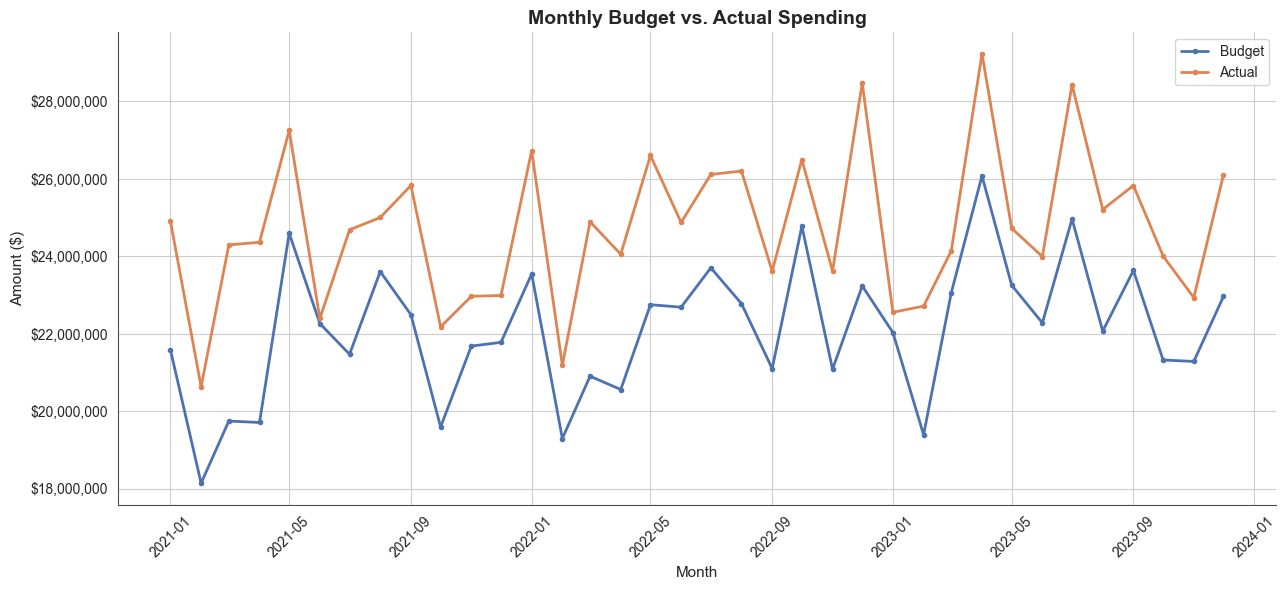

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(monthly['Month'], monthly['Budget'], label='Budget', color=BUDGET_COLOR, linewidth=2, marker='o', markersize=3)
ax.plot(monthly['Month'], monthly['Actual'], label='Actual', color=ACTUAL_COLOR, linewidth=2, marker='o', markersize=3)
ax.set_title('Monthly Budget vs. Actual Spending')
ax.set_ylabel('Amount ($)')
ax.set_xlabel('Month')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(currency_fmt))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

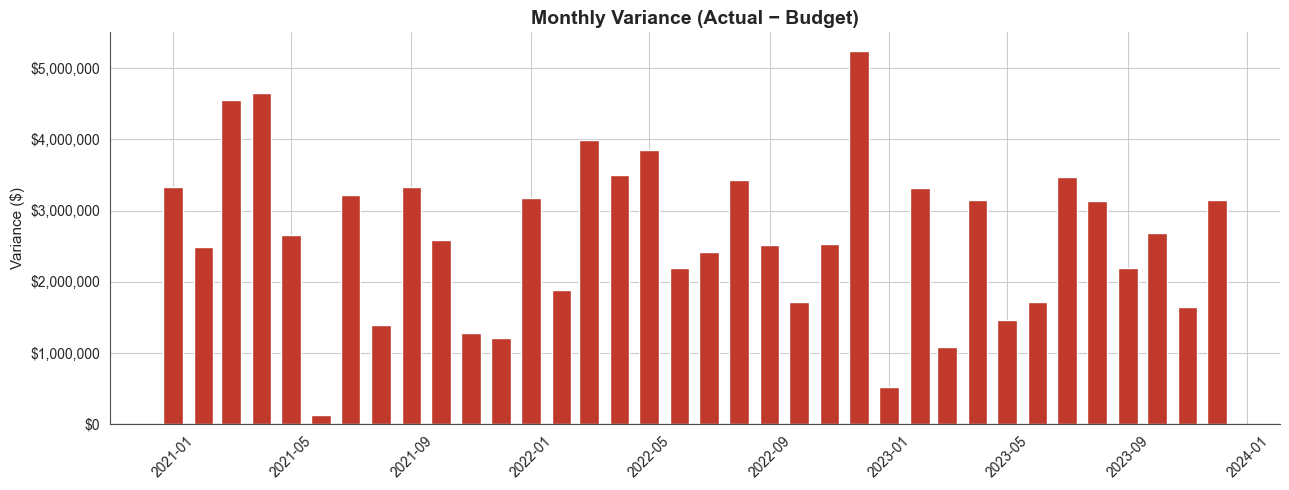

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))
colors = [UNFAV_COLOR if v > 0 else FAV_COLOR for v in monthly['Variance']]
ax.bar(monthly['Month'], monthly['Variance'], color=colors, width=20)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Monthly Variance (Actual − Budget)')
ax.set_ylabel('Variance ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(currency_fmt))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
spike_month = monthly.loc[monthly['Actual'].idxmax()]
worst_var_month = monthly.loc[monthly['Variance'].idxmax()]
best_var_month = monthly.loc[monthly['Variance'].idxmin()]
n_months_over = (monthly['Variance'] > 0).sum()
n_months_under = (monthly['Variance'] < 0).sum()

print(f"Highest single-month actual spending: {spike_month['Month'].strftime('%b %Y')} (${spike_month['Actual']:,.0f})")
print(f"Most unfavorable month: {worst_var_month['Month'].strftime('%b %Y')} (Variance: ${worst_var_month['Variance']:,.0f})")
print(f"Most favorable month: {best_var_month['Month'].strftime('%b %Y')} (Variance: ${best_var_month['Variance']:,.0f})")
print(f"\nMonths over budget:  {n_months_over} of {len(monthly)}")
print(f"Months under budget: {n_months_under} of {len(monthly)}")

Highest single-month actual spending: Apr 2023 ($29,230,433)
Most unfavorable month: Dec 2022 (Variance: $5,240,553)
Most favorable month: Jun 2021 (Variance: $131,217)

Months over budget:  36 of 36
Months under budget: 0 of 36


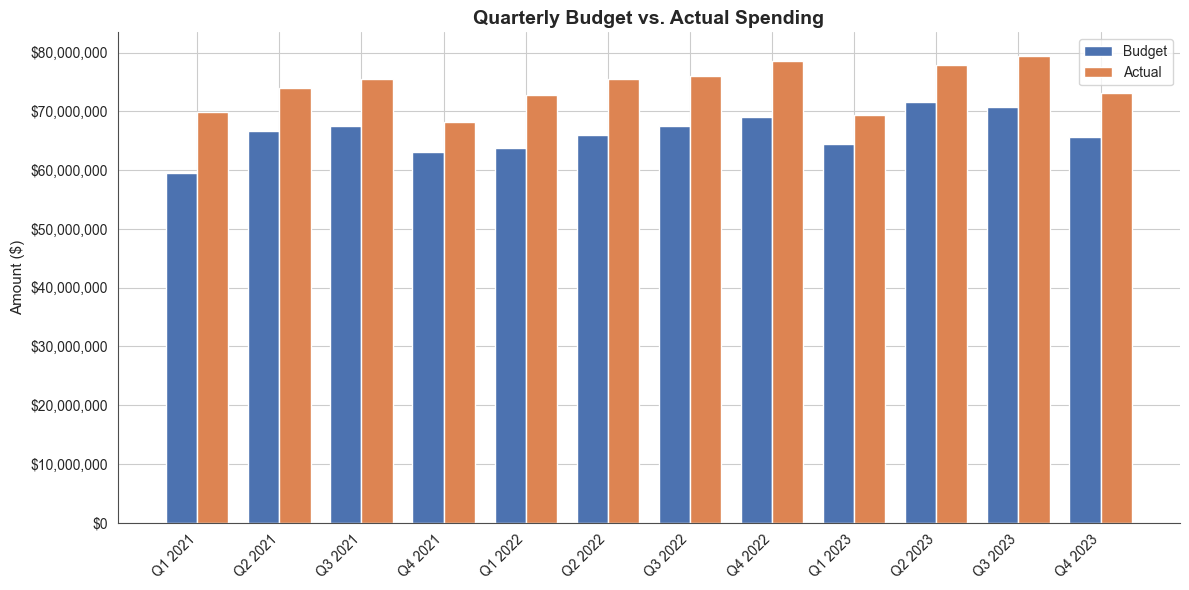

,Label,Budget,Actual,Variance,Variance %
0,Q1 2021,59477731,69841385,10363654,17.42
1,Q2 2021,66572432,74010713,7438281,11.17
2,Q3 2021,67573985,75519750,7945765,11.76
3,Q4 2021,63056872,68139238,5082366,8.06
4,Q1 2022,63747479,72805466,9057987,14.21
5,Q2 2022,66001367,75536302,9534935,14.45
6,Q3 2022,67584060,75932795,8348735,12.35
7,Q4 2022,69101630,78594587,9492957,13.74
8,Q1 2023,64491698,69415323,4923625,7.63
9,Q2 2023,71616416,77950272,6333856,8.84


In [ ]:
quarterly = df.groupby(['Year', 'Quarter']).agg(
    Budget=('Budget Amount', 'sum'),
    Actual=('Actual Amount', 'sum')
).reset_index()
quarterly['Variance'] = quarterly['Actual'] - quarterly['Budget']
quarterly['Variance %'] = (quarterly['Variance'] / quarterly['Budget']) * 100
quarterly['Label'] = 'Q' + quarterly['Quarter'].astype(str) + ' ' + quarterly['Year'].astype(str)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(quarterly))
width = 0.38
ax.bar(x - width/2, quarterly['Budget'], width, label='Budget', color=BUDGET_COLOR)
ax.bar(x + width/2, quarterly['Actual'], width, label='Actual', color=ACTUAL_COLOR)
ax.set_xticks(x)
ax.set_xticklabels(quarterly['Label'], rotation=45, ha='right')
ax.set_title('Quarterly Budget vs. Actual Spending')
ax.set_ylabel('Amount ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(currency_fmt))
ax.legend()
plt.tight_layout()
plt.show()

quarterly[['Label', 'Budget', 'Actual', 'Variance', 'Variance %']]

In [ ]:
yearly = df.groupby('Year').agg(
    Budget=('Budget Amount', 'sum'),
    Actual=('Actual Amount', 'sum')
).reset_index()
yearly['Variance'] = yearly['Actual'] - yearly['Budget']
yearly['Variance %'] = (yearly['Variance'] / yearly['Budget']) * 100
print(f"Years present in the dataset: {sorted(df['Year'].unique())}")
yearly

Years present in the dataset: [np.int32(2021), np.int32(2022), np.int32(2023)]


,Year,Budget,Actual,Variance,Variance %
0,2021,256681020,287511086,30830066,12.01
1,2022,266434536,302869150,36434614,13.67
2,2023,272353700,299886793,27533093,10.11


**Observations:** The monthly view shows how closely actual spending tracks the budget line over time and highlights any specific months where actual spending spiked well above (or fell well below) plan. The quarterly and yearly rollups smooth out month-to-month noise and reveal whether unfavorable variance is a persistent, worsening trend or an isolated event concentrated in specific periods.

## 12. Department × Category Analysis

Combining department and category dimensions reveals *which specific combinations* — not just which department or which category in isolation — carry the largest unfavorable variance. This is often the most actionable level of analysis for budget owners.

In [ ]:
dc_summary = df.groupby(['Department', 'Category']).agg(
    Budget=('Budget Amount', 'sum'),
    Actual=('Actual Amount', 'sum'),
    Transaction_Count=('Transaction ID', 'count')
).reset_index()
dc_summary['Variance'] = dc_summary['Actual'] - dc_summary['Budget']
dc_summary['Variance %'] = (dc_summary['Variance'] / dc_summary['Budget']) * 100
dc_summary['Budget Utilization %'] = (dc_summary['Actual'] / dc_summary['Budget']) * 100
dc_summary.rename(columns={'Transaction_Count': 'Transaction Count'}, inplace=True)
print(f"Total Department x Category combinations: {len(dc_summary)}")
dc_summary.sort_values('Variance', ascending=False).head(10)

Total Department x Category combinations: 38


,Department,Category,Budget,Actual,Transaction Count,Variance,Variance %,Budget Utilization %
21,Marketing,Training,21294820,26796378,280,5501558,25.84,125.84
22,Marketing,Travel,20727724,24862371,274,4134647,19.95,119.95
26,Operations,Salaries,19686711,23803114,258,4116403,20.91,120.91
36,Sales,Utilities,22308763,26387064,288,4078301,18.28,118.28
30,Operations,Utilities,23738950,27727006,305,3988056,16.80,116.80
14,IT,Salaries,19840742,23815157,265,3974415,20.03,120.03
9,HR,Training,23139073,26838701,295,3699628,15.99,115.99
25,Operations,Marketing,20366640,23988226,261,3621586,17.78,117.78
19,Marketing,Marketing,23587963,27159617,297,3571654,15.14,115.14
20,Marketing,Salaries,20971783,24476425,273,3504642,16.71,116.71


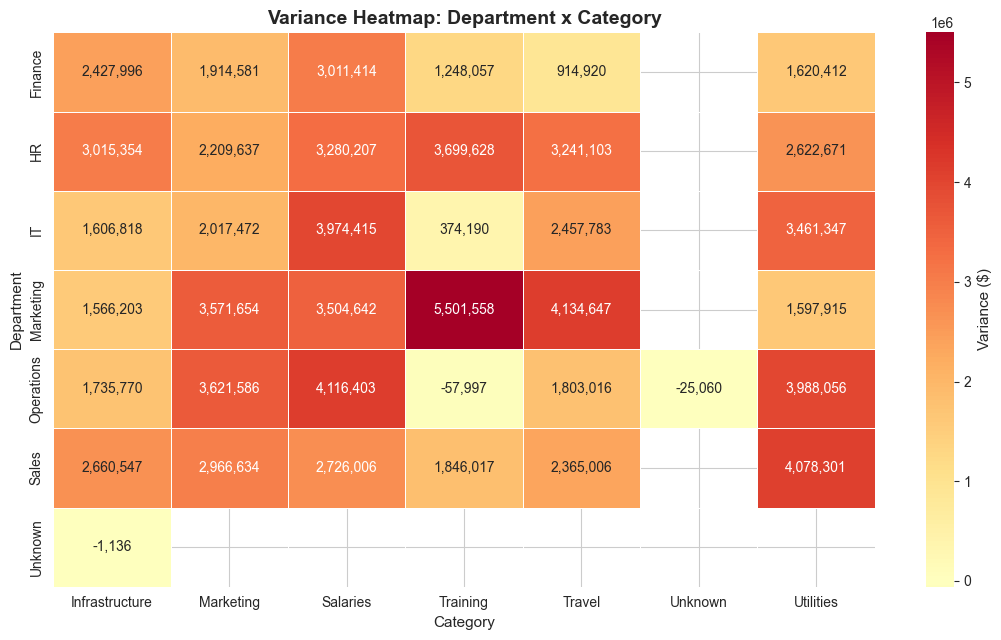

In [ ]:
heatmap_data = dc_summary.pivot(index='Department', columns='Category', values='Variance')

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.heatmap(heatmap_data, annot=True, fmt=',.0f', cmap='RdYlGn_r', center=0,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Variance ($)'}, ax=ax)
ax.set_title('Variance Heatmap: Department x Category')
plt.tight_layout()
plt.show()

In [ ]:
top10_unfav_combos = dc_summary.sort_values('Variance', ascending=False).head(10).reset_index(drop=True)
top10_unfav_combos[['Department', 'Category', 'Budget', 'Actual', 'Variance', 'Variance %', 'Budget Utilization %', 'Transaction Count']]

,Department,Category,Budget,Actual,Variance,Variance %,Budget Utilization %,Transaction Count
0,Marketing,Training,21294820,26796378,5501558,25.84,125.84,280
1,Marketing,Travel,20727724,24862371,4134647,19.95,119.95,274
2,Operations,Salaries,19686711,23803114,4116403,20.91,120.91,258
3,Sales,Utilities,22308763,26387064,4078301,18.28,118.28,288
4,Operations,Utilities,23738950,27727006,3988056,16.80,116.80,305
5,IT,Salaries,19840742,23815157,3974415,20.03,120.03,265
6,HR,Training,23139073,26838701,3699628,15.99,115.99,295
7,Operations,Marketing,20366640,23988226,3621586,17.78,117.78,261
8,Marketing,Marketing,23587963,27159617,3571654,15.14,115.14,297
9,Marketing,Salaries,20971783,24476425,3504642,16.71,116.71,273


In [ ]:
top_combo = top10_unfav_combos.iloc[0]
top_util_combo = dc_summary.sort_values('Budget Utilization %', ascending=False).iloc[0]
print(f"Largest unfavorable combination: {top_combo['Department']} / {top_combo['Category']} "
      f"(Variance: ${top_combo['Variance']:,.0f}, {top_combo['Variance %']:.2f}%)")
print(f"Highest budget-utilization combination: {top_util_combo['Department']} / {top_util_combo['Category']} "
      f"({top_util_combo['Budget Utilization %']:.2f}%)")
print(f"\nCombinations requiring management attention (Variance > $0 AND Budget Utilization > 110%): "
      f"{((dc_summary['Variance'] > 0) & (dc_summary['Budget Utilization %'] > 110)).sum()} of {len(dc_summary)}")

Largest unfavorable combination: Marketing / Training (Variance: $5,501,558, 25.84%)
Highest budget-utilization combination: Marketing / Training (125.84%)

Combinations requiring management attention (Variance > $0 AND Budget Utilization > 110%): 23 of 38


**Why this matters:** Department-level and category-level views can each mask the real driver of overspending — a department may look only mildly over budget in aggregate while one specific category within it is severely overspent (offset by savings elsewhere). The heatmap and Top 10 table above isolate exactly which combinations budget owners should prioritize for review.

## 13. Transaction-Level Variance Analysis

We surface the individual transactions with the largest unfavorable variance for further investigation. This is a list for follow-up review — it does not imply any transaction is fraudulent or erroneous without further evidence.

In [ ]:
top_transactions = df.sort_values('Variance', ascending=False).head(15)[
    ['Transaction ID', 'Date', 'Department', 'Category', 'Region',
     'Budget Amount', 'Actual Amount', 'Variance', 'Variance %']
].reset_index(drop=True)
top_transactions

,Transaction ID,Date,Department,Category,Region,Budget Amount,Actual Amount,Variance,Variance %
0,TXN100284,2022-10-16,Operations,Travel,South,10785,169522,158737,"1,471.83"
1,TXN102244,2022-07-13,Marketing,Marketing,Central,11548,169812,158264,"1,370.49"
2,TXN103049,2022-09-20,Operations,Salaries,South,11702,167809,156107,"1,334.02"
3,TXN104685,2022-12-06,Operations,Utilities,South,14188,169923,155735,"1,097.65"
4,TXN102866,2023-02-15,Operations,Infrastructure,Central,12829,168514,155685,"1,213.54"
5,TXN105341,2023-09-08,Marketing,Travel,Central,10770,166097,155327,"1,442.22"
6,TXN106299,2022-05-11,Sales,Travel,East,14226,168745,154519,"1,086.17"
7,TXN108028,2021-07-11,IT,Training,North,13249,167180,153931,"1,161.83"
8,TXN104727,2023-07-29,IT,Travel,North,15976,169799,153823,962.84
9,TXN106328,2022-11-11,HR,Infrastructure,Central,14353,167987,153634,"1,070.40"


These transactions represent the single largest dollar overruns in the dataset and are natural candidates for finance teams to review individually — to confirm whether they reflect legitimate one-off costs (e.g., an emergency purchase) or data/process issues.

## 14. Outlier Analysis

We use the IQR (interquartile range) method to flag statistically unusual values in `Actual Amount` and `Variance`. An outlier here is a value that falls more than 1.5×IQR below Q1 or above Q3 — a standard, explainable threshold for identifying atypical observations without assuming a specific distribution.

In [ ]:
def iqr_bounds(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

actual_lo, actual_hi = iqr_bounds(df['Actual Amount'])
var_lo, var_hi = iqr_bounds(df['Variance'])

df['Actual_Outlier'] = (df['Actual Amount'] < actual_lo) | (df['Actual Amount'] > actual_hi)
df['Variance_Outlier'] = (df['Variance'] < var_lo) | (df['Variance'] > var_hi)

print(f"Actual Amount outlier bounds: [{actual_lo:,.0f}, {actual_hi:,.0f}]")
print(f"Actual Amount outliers: {df['Actual_Outlier'].sum()} ({df['Actual_Outlier'].mean()*100:.2f}% of transactions)")
print(f"\nVariance outlier bounds: [{var_lo:,.0f}, {var_hi:,.0f}]")
print(f"Variance outliers: {df['Variance_Outlier'].sum()} ({df['Variance_Outlier'].mean()*100:.2f}% of transactions)")

Actual Amount outlier bounds: [-74,493, 253,644]
Actual Amount outliers: 0 (0.00% of transactions)

Variance outlier bounds: [-168,853, 188,072]
Variance outliers: 0 (0.00% of transactions)


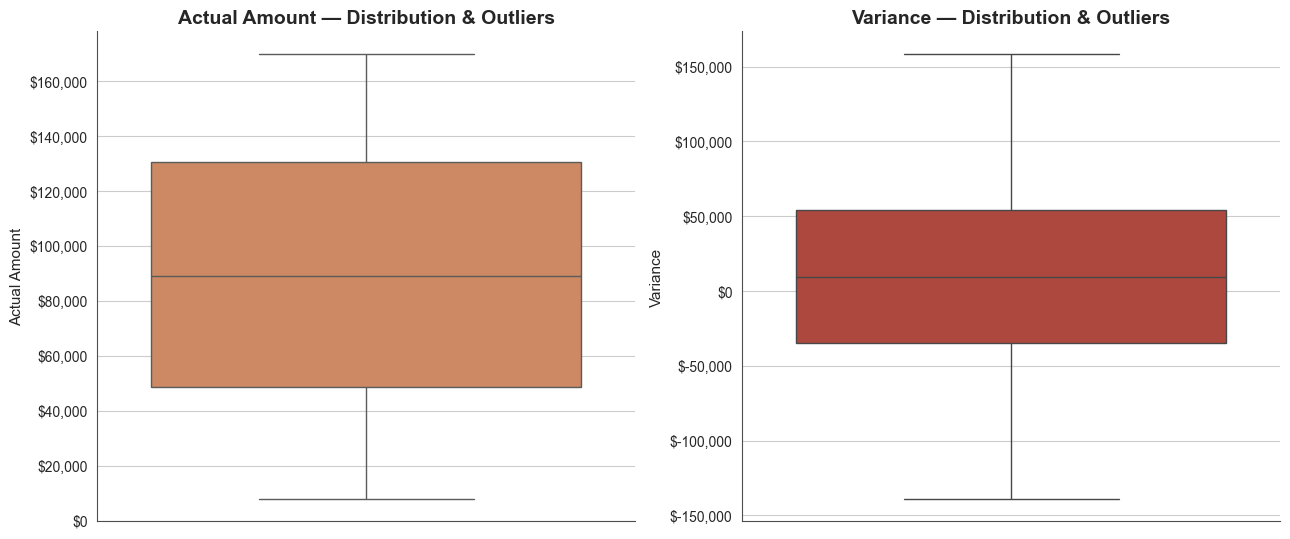

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.boxplot(y=df['Actual Amount'], ax=axes[0], color=ACTUAL_COLOR)
axes[0].set_title('Actual Amount — Distribution & Outliers')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(currency_fmt))

sns.boxplot(y=df['Variance'], ax=axes[1], color=UNFAV_COLOR)
axes[1].set_title('Variance — Distribution & Outliers')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(currency_fmt))

plt.tight_layout()
plt.show()

In [ ]:
outlier_by_dept = df.loc[df['Variance_Outlier'], 'Department'].value_counts()
outlier_by_cat = df.loc[df['Variance_Outlier'], 'Category'].value_counts()
print("Variance outliers by Department:")
print(outlier_by_dept)
print("\nVariance outliers by Category:")
print(outlier_by_cat)

Variance outliers by Department:
Series([], Name: count, dtype: int64)

Variance outliers by Category:
Series([], Name: count, dtype: int64)


**Should outliers be removed?** No. Unlike a data-entry error, these are legitimate high-value transactions — the underlying `Budget Amount` and `Actual Amount` fields showed no invalid values, negative numbers, or corrupted entries. Removing them would understate real spending and hide exactly the kind of large-dollar variance that business stakeholders most need visibility into. They are retained in all analysis and instead flagged for targeted follow-up (see the Transaction-Level table above).

## 15. Statistical Analysis

We examine the statistical relationship between `Budget Amount` and `Actual Amount`, and the distribution shape of `Variance` and `Variance %`.

In [ ]:
correlation = df['Budget Amount'].corr(df['Actual Amount'])
print(f"Correlation between Budget Amount and Actual Amount: {correlation:.4f}")

Correlation between Budget Amount and Actual Amount: 0.0113


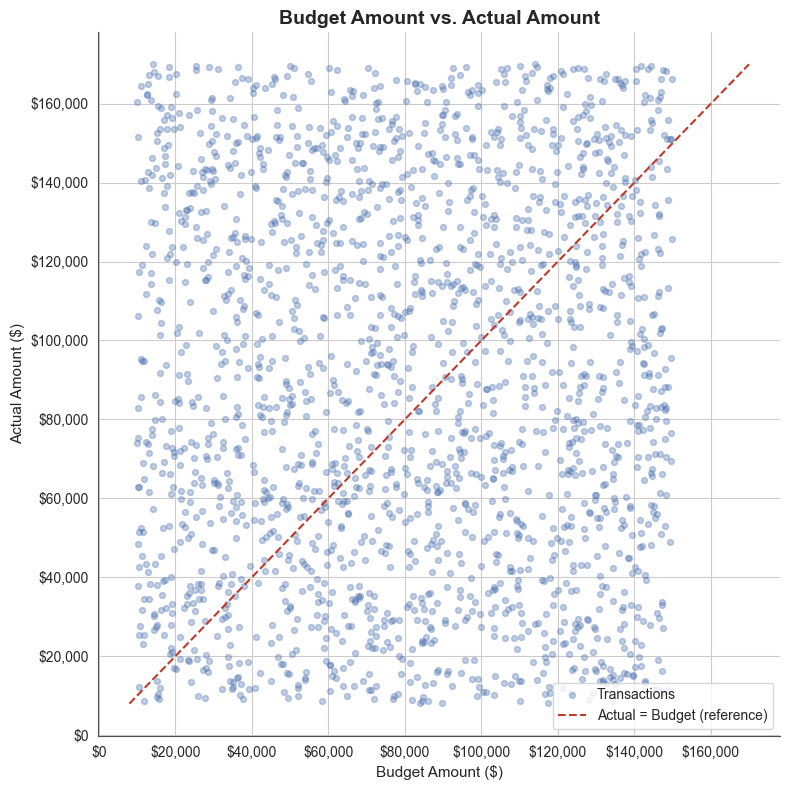

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
sample = df.sample(min(2000, len(df)), random_state=42)
ax.scatter(sample['Budget Amount'], sample['Actual Amount'], alpha=0.35, s=18, color=BUDGET_COLOR, label='Transactions')

lims = [min(df['Budget Amount'].min(), df['Actual Amount'].min()),
        max(df['Budget Amount'].max(), df['Actual Amount'].max())]
ax.plot(lims, lims, color=UNFAV_COLOR, linestyle='--', linewidth=1.5, label='Actual = Budget (reference)')

ax.set_xlabel('Budget Amount ($)')
ax.set_ylabel('Actual Amount ($)')
ax.set_title('Budget Amount vs. Actual Amount')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(currency_fmt))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(currency_fmt))
ax.legend()
plt.tight_layout()
plt.show()

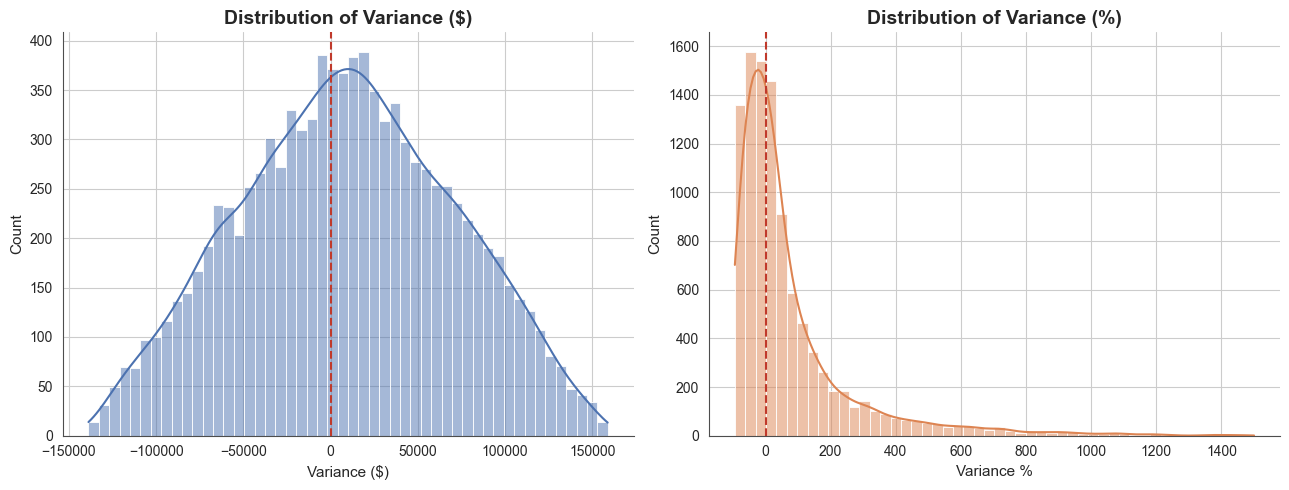

         Variance  Variance %
count   10,000.00   10,000.00
mean     9,479.78       73.41
std     61,660.07      194.44
min   -138,773.00      -94.20
25%    -35,006.00      -38.80
50%      9,518.00       11.72
75%     54,225.25      101.61
max    158,737.00    1,500.09


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df['Variance'], bins=50, kde=True, ax=axes[0], color=BUDGET_COLOR)
axes[0].axvline(0, color=UNFAV_COLOR, linestyle='--')
axes[0].set_title('Distribution of Variance ($)')
axes[0].set_xlabel('Variance ($)')

sns.histplot(df['Variance %'], bins=50, kde=True, ax=axes[1], color=ACTUAL_COLOR)
axes[1].axvline(0, color=UNFAV_COLOR, linestyle='--')
axes[1].set_title('Distribution of Variance (%)')
axes[1].set_xlabel('Variance %')

plt.tight_layout()
plt.show()

print(df[['Variance', 'Variance %']].describe())

In [ ]:
var_skew = stats.skew(df['Variance'].dropna())
print(f"Skewness of Variance distribution: {var_skew:.3f}")
if abs(var_skew) < 0.5:
    skew_desc = 'approximately symmetric'
elif var_skew > 0:
    skew_desc = 'right-skewed (a tail of large unfavorable variances pulls the mean above the median)'
else:
    skew_desc = 'left-skewed (a tail of large favorable variances pulls the mean below the median)'
print(f"The distribution is {skew_desc}.")

Skewness of Variance distribution: 0.000
The distribution is approximately symmetric.


**Interpretation:** A strong, close-to-linear relationship between Budget and Actual amounts (points clustering near the reference line) would indicate that spending generally tracks planned budgets at the transaction level, with variance arising from many small deviations rather than systemic misallocation. Points that fall consistently above the reference line reflect the unfavorable-variance transactions already identified in earlier sections. No further statistical tests are run here, since correlation and distribution shape are sufficient to answer the business question of *how* Actual relates to Budget without adding complexity that would not change the recommendations.

## 16. Consistency Analysis

A single large variance is a different business problem than a department or category that *repeatedly* runs over budget month after month. Here we measure how consistently each department and category exceeds its budget across the monthly periods in the dataset.

In [ ]:
dept_monthly = df.groupby(['Department', df['Date'].dt.to_period('M')]).agg(
    Budget=('Budget Amount', 'sum'), Actual=('Actual Amount', 'sum')
).reset_index()
dept_monthly['Variance %'] = (dept_monthly['Actual'] - dept_monthly['Budget']) / dept_monthly['Budget'] * 100

consistency = dept_monthly.groupby('Department').agg(
    Periods_Over_Budget=('Variance %', lambda s: (s > 0).sum()),
    Periods_Under_Budget=('Variance %', lambda s: (s < 0).sum()),
    Total_Periods=('Variance %', 'count'),
    Avg_Variance_Pct=('Variance %', 'mean')
).reset_index()
consistency['Pct_Periods_Over_Budget'] = (consistency['Periods_Over_Budget'] / consistency['Total_Periods'] * 100).round(2)
consistency = consistency.merge(
    dept_summary[['Department', 'Variance']], on='Department'
).rename(columns={'Variance': 'Total Unfavorable Variance ($)', 'Avg_Variance_Pct': 'Avg Variance %'})
consistency = consistency.sort_values('Pct_Periods_Over_Budget', ascending=False).reset_index(drop=True)
consistency[['Department', 'Periods_Over_Budget', 'Periods_Under_Budget', 'Total_Periods',
             'Pct_Periods_Over_Budget', 'Avg Variance %', 'Total Unfavorable Variance ($)']]

,Department,Periods_Over_Budget,Periods_Under_Budget,Total_Periods,Pct_Periods_Over_Budget,Avg Variance %,Total Unfavorable Variance ($)
0,Marketing,34,2,36,94.44,15.43,19876619
1,HR,33,3,36,91.67,13.48,18068600
2,Sales,32,4,36,88.89,12.82,16642511
3,Operations,27,9,36,75.00,12.57,15181774
4,IT,26,10,36,72.22,11.59,13892025
5,Finance,25,11,36,69.44,9.47,11137380
6,Unknown,0,1,1,0.00,-0.98,-1136


In [ ]:
most_consistent_overspender = consistency.iloc[0]
print(f"Most consistently over-budget department: {most_consistent_overspender['Department']} — "
      f"over budget in {most_consistent_overspender['Periods_Over_Budget']} of "
      f"{most_consistent_overspender['Total_Periods']} months "
      f"({most_consistent_overspender['Pct_Periods_Over_Budget']:.1f}% of periods), "
      f"averaging {most_consistent_overspender['Avg Variance %']:.2f}% variance per month.")

Most consistently over-budget department: Marketing — over budget in 34 of 36 months (94.4% of periods), averaging 15.43% variance per month.


**Why consistency matters:** A department that is over budget in the large majority of months, even if by a modest amount each time, points to a structural under-budgeting issue (the plan itself needs revisiting) rather than an isolated spike that better budget-period controls could catch. This distinction directly informs the prioritization framework in the next section.

## 17. Forecasting

The dataset spans multiple years of monthly data, which is sufficient for a simple, explainable forecast of near-term spending. We use **linear regression on the monthly Actual Amount series** — a transparent, easily-explained method appropriate for a directional forecast, rather than a complex model that would be harder to justify to business stakeholders.

**Assumptions & limitations:**
- The forecast assumes the recent linear trend in monthly spending continues; it does **not** account for seasonality, one-off events, or planned future budget changes.
- With only a few years of monthly data, the model has limited ability to detect seasonal patterns with confidence.
- This forecast should be treated as **directional guidance**, not a guaranteed figure — it is intended to support budget-planning conversations, not to replace them.


In [ ]:
n_periods = len(monthly)
print(f"Monthly periods available for forecasting: {n_periods}")

if n_periods >= 6:
    X = np.arange(n_periods).reshape(-1, 1)
    y = monthly['Actual'].values

    model = LinearRegression()
    model.fit(X, y)

    future_periods = 3
    X_future = np.arange(n_periods, n_periods + future_periods).reshape(-1, 1)
    forecast_values = model.predict(X_future)

    last_month = monthly['Month'].iloc[-1]
    future_months = pd.date_range(last_month + pd.DateOffset(months=1), periods=future_periods, freq='MS')

    forecast_df = pd.DataFrame({'Month': future_months, 'Forecasted Actual': forecast_values})
    r_squared = model.score(X, y)
    print(f"Linear trend R-squared on historical monthly Actual spending: {r_squared:.3f}")
    print(forecast_df)
else:
    forecast_df = None
    print("Not enough monthly periods for a meaningful forecast — forecasting section skipped.")

Monthly periods available for forecasting: 36
Linear trend R-squared on historical monthly Actual spending: 0.062
       Month  Forecasted Actual
0 2024-01-01      25,596,632.87
1 2024-02-01      25,643,497.36
2 2024-03-01      25,690,361.86


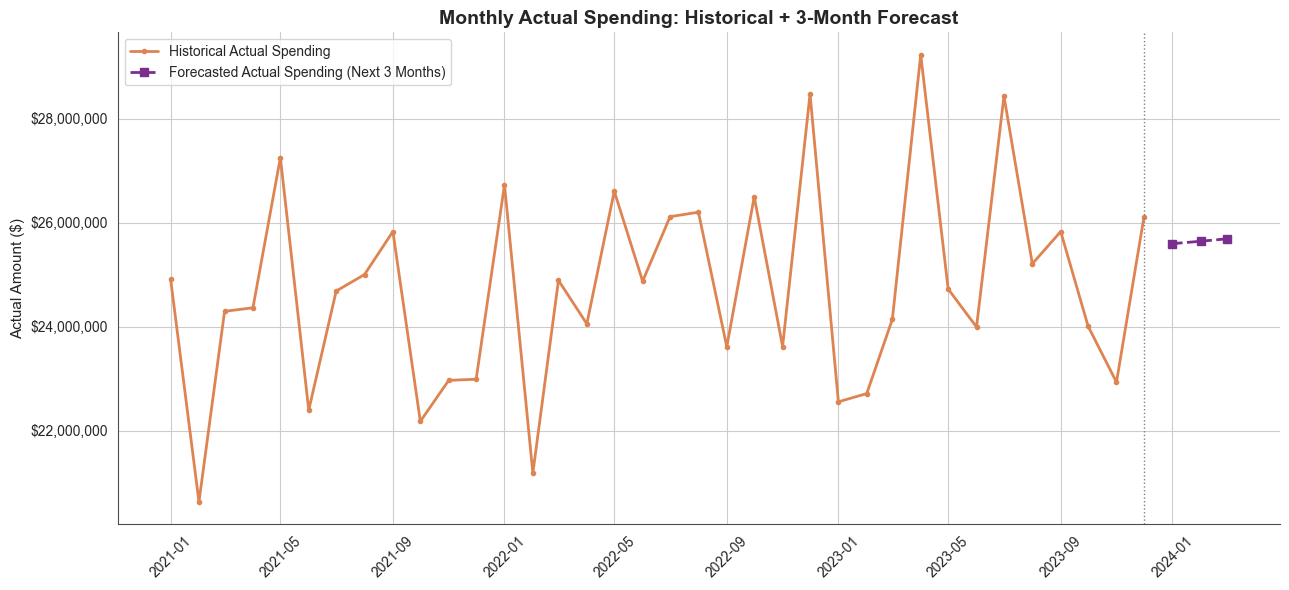

In [ ]:
if forecast_df is not None:
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(monthly['Month'], monthly['Actual'], label='Historical Actual Spending',
            color=ACTUAL_COLOR, marker='o', markersize=3, linewidth=2)
    ax.plot(forecast_df['Month'], forecast_df['Forecasted Actual'], label='Forecasted Actual Spending (Next 3 Months)',
            color='#7A2E8E', marker='s', markersize=6, linewidth=2, linestyle='--')
    ax.axvline(monthly['Month'].iloc[-1], color='gray', linestyle=':', linewidth=1)
    ax.set_title('Monthly Actual Spending: Historical + 3-Month Forecast')
    ax.set_ylabel('Actual Amount ($)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(currency_fmt))
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping forecast chart — insufficient historical periods.")

**Reading the forecast:** The dashed segment is a linear extrapolation of the historical trend line, not a prediction that accounts for department-level budget decisions, seasonality, or business changes. It should be used to prompt a planning conversation ("if current trends continue, spending is directionally headed here") rather than as a committed number.

## 18. Business Segmentation / Prioritization

We classify each Department × Category combination into a management-priority tier, using data-driven thresholds (quantiles of unfavorable variance and consistency of overspending) rather than arbitrary cutoffs.

**Rule definition:**
- **High Priority** — Variance is in the top third (67th percentile or higher) of unfavorable combinations AND Budget Utilization exceeds 110%.
- **Monitor** — Positive variance that doesn't meet the High Priority threshold, i.e. moderate or inconsistent overspending.
- **Stable** — Variance is zero or favorable (Budget Utilization at or below 100%).


In [ ]:
unfav_combos = dc_summary[dc_summary['Variance'] > 0]
if len(unfav_combos) > 0:
    variance_67th = unfav_combos['Variance'].quantile(0.67)
else:
    variance_67th = 0
print(f"67th percentile of unfavorable-combination variance: ${variance_67th:,.0f}")

def classify(row):
    if row['Variance'] <= 0:
        return 'Stable'
    if row['Variance'] >= variance_67th and row['Budget Utilization %'] > 110:
        return 'High Priority'
    return 'Monitor'

dc_summary['Priority Tier'] = dc_summary.apply(classify, axis=1)
tier_counts = dc_summary['Priority Tier'].value_counts()
print("\nCombinations per tier:")
print(tier_counts)

67th percentile of unfavorable-combination variance: $3,271,604

Combinations per tier:
Priority Tier
Monitor          23
High Priority    12
Stable            3
Name: count, dtype: int64


In [ ]:
priority_summary = dc_summary.sort_values(['Priority Tier', 'Variance'], ascending=[True, False])[
    ['Department', 'Category', 'Budget', 'Actual', 'Variance', 'Variance %',
     'Budget Utilization %', 'Priority Tier']
].reset_index(drop=True)
priority_summary[priority_summary['Priority Tier'] == 'High Priority']

,Department,Category,Budget,Actual,Variance,Variance %,Budget Utilization %,Priority Tier
0,Marketing,Training,21294820,26796378,5501558,25.84,125.84,High Priority
1,Marketing,Travel,20727724,24862371,4134647,19.95,119.95,High Priority
2,Operations,Salaries,19686711,23803114,4116403,20.91,120.91,High Priority
3,Sales,Utilities,22308763,26387064,4078301,18.28,118.28,High Priority
4,Operations,Utilities,23738950,27727006,3988056,16.80,116.80,High Priority
5,IT,Salaries,19840742,23815157,3974415,20.03,120.03,High Priority
6,HR,Training,23139073,26838701,3699628,15.99,115.99,High Priority
7,Operations,Marketing,20366640,23988226,3621586,17.78,117.78,High Priority
8,Marketing,Marketing,23587963,27159617,3571654,15.14,115.14,High Priority
9,Marketing,Salaries,20971783,24476425,3504642,16.71,116.71,High Priority


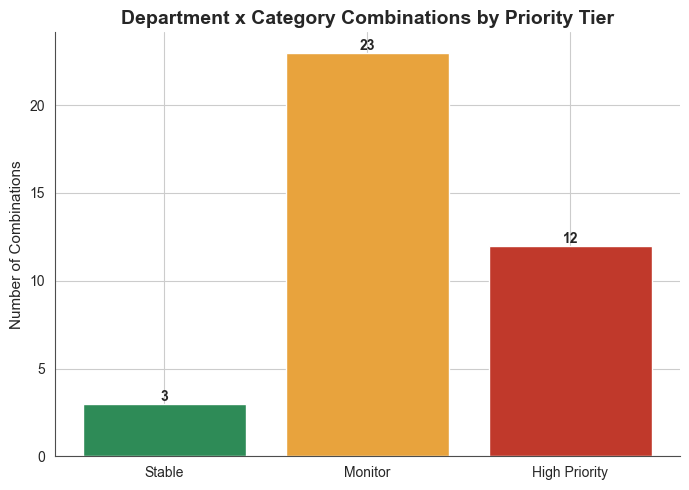

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
tier_order = ['Stable', 'Monitor', 'High Priority']
counts_ordered = tier_counts.reindex(tier_order).fillna(0)
colors_tier = [FAV_COLOR, '#E8A33D', UNFAV_COLOR]
ax.bar(counts_ordered.index, counts_ordered.values, color=colors_tier)
ax.set_title('Department x Category Combinations by Priority Tier')
ax.set_ylabel('Number of Combinations')
for i, v in enumerate(counts_ordered.values):
    ax.text(i, v, int(v), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

This tiering translates the raw variance analysis into a clear management action list: **High Priority** combinations warrant immediate budget review, **Monitor** combinations should be watched over the next reporting cycle, and **Stable** combinations require no intervention.

## 19. Key Business Insights

*(Each insight below references the actual calculated values from this analysis.)*

In [ ]:
insights = []

insights.append(
    f"1. Across {n_transactions:,} transactions, total actual spending of ${total_actual:,.0f} against a "
    f"budget of ${total_budget:,.0f} results in an overall variance of ${total_variance:,.0f} "
    f"({overall_variance_pct:.2f}%), putting the organization {status} on aggregate."
)

insights.append(
    f"2. {top_over_dept['Department']} recorded the highest unfavorable department-level variance of "
    f"${top_over_dept['Variance']:,.0f}, exceeding its budget by {top_over_dept['Variance %']:.2f}%."
)

insights.append(
    f"3. '{top_unfav_cat}' is the single largest contributor to unfavorable variance across the organization, "
    f"accounting for {top_unfav_cat_share:.2f}% of all overspending."
)

insights.append(
    f"4. {top_over_region['Region']} is the region with the highest budget overrun, with a variance of "
    f"${top_over_region['Variance']:,.0f} ({top_over_region['Variance %']:.2f}%)."
)

insights.append(
    f"5. The {top_combo['Department']} / {top_combo['Category']} combination shows the largest unfavorable "
    f"variance of any department-category pair, at ${top_combo['Variance']:,.0f} "
    f"({top_combo['Variance %']:.2f}%), making it the top candidate for immediate review."
)

insights.append(
    f"6. {most_consistent_overspender['Department']} exceeded its budget in "
    f"{most_consistent_overspender['Periods_Over_Budget']} of {most_consistent_overspender['Total_Periods']} "
    f"observed months ({most_consistent_overspender['Pct_Periods_Over_Budget']:.1f}% of periods), indicating a "
    f"persistent rather than one-off overspending pattern."
)

insights.append(
    f"7. {pct_over_budget:.2f}% of all individual transactions exceeded their budgeted amount, compared with "
    f"{pct_under_budget:.2f}% that came in under budget."
)

insights.append(
    f"8. The business segmentation analysis identifies {int(tier_counts.get('High Priority', 0))} "
    f"department-category combinations as High Priority for management intervention, out of "
    f"{len(dc_summary)} total combinations analyzed."
)

for i in insights:
    print(i, '\n')

1. Across 10,000 transactions, total actual spending of $890,267,029 against a budget of $795,469,256 results in an overall variance of $94,797,773 (11.92%), putting the organization OVER budget on aggregate. 

2. Marketing recorded the highest unfavorable department-level variance of $19,876,619, exceeding its budget by 15.06%. 

3. 'Utilities' is the single largest contributor to unfavorable variance across the organization, accounting for 17.51% of all overspending. 

4. East is the region with the highest budget overrun, with a variance of $21,391,177 (13.40%). 

5. The Marketing / Training combination shows the largest unfavorable variance of any department-category pair, at $5,501,558 (25.84%), making it the top candidate for immediate review. 

6. Marketing exceeded its budget in 34 of 36 observed months (94.4% of periods), indicating a persistent rather than one-off overspending pattern. 

7. 55.90% of all individual transactions exceeded their budgeted amount, compared with 44

## 20. Actionable Business Recommendations

Each recommendation below is generated directly from the computed results (executed in the next cell) so that it always reflects the actual data — not hard-coded values.

In [ ]:
from IPython.display import Markdown, display

recommendations_md = f"""
1. **Conduct an immediate budget review for {top_over_dept['Department']} and the {top_combo['Department']}/{top_combo['Category']} combination.** These represent the largest single sources of unfavorable variance identified in the Department and Department x Category analyses, and should be the first stop for finance business partners.

2. **Set category-specific spending controls for '{top_unfav_cat}'.** Because this category alone accounts for {top_unfav_cat_share:.1f}% of total unfavorable variance across *all* departments, a category-level control (e.g., pre-approval thresholds) would have organization-wide impact rather than fixing one department in isolation.

3. **Investigate the recurring overspending pattern in {most_consistent_overspender['Department']}.** Since this department was over budget in {most_consistent_overspender['Pct_Periods_Over_Budget']:.0f}% of observed months, the issue is unlikely to be resolved by a single corrective action -- it points to the *original budget* being set too low relative to actual operating needs, and the budget itself should be revised for the next planning cycle.

4. **Review the Top 15 highest-variance individual transactions for legitimacy.** These large-dollar transactions should be confirmed as valid business expenses (not entry errors) as part of routine month-end close procedures.

5. **Apply the High Priority / Monitor / Stable tiering as a recurring management reporting tool.** Re-running this classification each reporting period will let finance leadership track whether High Priority combinations are improving or worsening over time, rather than relying on ad hoc variance checks.

6. **Use the 3-month directional forecast to inform -- not replace -- the next budget cycle's planning conversations,** given current spending trends, while accounting for the forecast's stated limitations (no seasonality or business-driver adjustment).
"""
display(Markdown(recommendations_md))


1. **Conduct an immediate budget review for Marketing and the Marketing/Training combination.** These represent the largest single sources of unfavorable variance identified in the Department and Department x Category analyses, and should be the first stop for finance business partners.

2. **Set category-specific spending controls for 'Utilities'.** Because this category alone accounts for 17.5% of total unfavorable variance across *all* departments, a category-level control (e.g., pre-approval thresholds) would have organization-wide impact rather than fixing one department in isolation.

3. **Investigate the recurring overspending pattern in Marketing.** Since this department was over budget in 94% of observed months, the issue is unlikely to be resolved by a single corrective action -- it points to the *original budget* being set too low relative to actual operating needs, and the budget itself should be revised for the next planning cycle.

4. **Review the Top 15 highest-variance individual transactions for legitimacy.** These large-dollar transactions should be confirmed as valid business expenses (not entry errors) as part of routine month-end close procedures.

5. **Apply the High Priority / Monitor / Stable tiering as a recurring management reporting tool.** Re-running this classification each reporting period will let finance leadership track whether High Priority combinations are improving or worsening over time, rather than relying on ad hoc variance checks.

6. **Use the 3-month directional forecast to inform -- not replace -- the next budget cycle's planning conversations,** given current spending trends, while accounting for the forecast's stated limitations (no seasonality or business-driver adjustment).


## 21. Executive Summary

The summary below is generated from the actual computed results in this notebook (executed in the next cell).

In [ ]:
exec_summary_md = f"""
### Situation
This analysis examined {n_transactions:,} budget-vs-actual financial transactions spanning {n_departments} departments, {n_categories} expense categories, and {n_regions} regions from {int(df['Year'].min())} to {int(df['Year'].max())}, comparing planned budgets against actual spending to identify the sources of budget variance.

### Key Findings
- Total actual spending of ${total_actual:,.0f} against a total budget of ${total_budget:,.0f} produced an overall variance of ${total_variance:,.0f} ({overall_variance_pct:.2f}%).
- **{top_over_dept['Department']}** is the largest single source of departmental overspending (${top_over_dept['Variance']:,.0f} unfavorable variance), and **{top_unfav_cat}** is the largest category-level contributor, responsible for {top_unfav_cat_share:.1f}% of all unfavorable variance organization-wide.
- The **{top_combo['Department']} / {top_combo['Category']}** combination is the single highest-priority pairing for corrective action.
- **{most_consistent_overspender['Department']}** exceeded its budget in {most_consistent_overspender['Pct_Periods_Over_Budget']:.0f}% of observed months -- a persistent, structural pattern rather than an isolated event.
- {int(tier_counts.get('High Priority', 0))} of {len(dc_summary)} department-category combinations are classified as High Priority for immediate management review.

### Business Impact
Unfavorable variance concentrated in a small number of departments, categories, and combinations means targeted intervention -- rather than an organization-wide spending freeze -- can address the majority of the overrun efficiently. Left unaddressed, the recurring nature of the overspending in the flagged areas suggests the gap will persist or widen in future budget cycles.

### Recommended Actions
Prioritize budget reviews for the departments, categories, and combinations flagged as High Priority above; revise the underlying budget for consistently over-budget departments rather than relying on after-the-fact corrections; and adopt the priority-tier framework as a recurring (e.g., monthly or quarterly) management reporting tool.
"""
display(Markdown(exec_summary_md))


### Situation
This analysis examined 10,000 budget-vs-actual financial transactions spanning 6 departments, 6 expense categories, and 5 regions from 2021 to 2023, comparing planned budgets against actual spending to identify the sources of budget variance.

### Key Findings
- Total actual spending of $890,267,029 against a total budget of $795,469,256 produced an overall variance of $94,797,773 (11.92%).
- **Marketing** is the largest single source of departmental overspending ($19,876,619 unfavorable variance), and **Utilities** is the largest category-level contributor, responsible for 17.5% of all unfavorable variance organization-wide.
- The **Marketing / Training** combination is the single highest-priority pairing for corrective action.
- **Marketing** exceeded its budget in 94% of observed months -- a persistent, structural pattern rather than an isolated event.
- 12 of 38 department-category combinations are classified as High Priority for immediate management review.

### Business Impact
Unfavorable variance concentrated in a small number of departments, categories, and combinations means targeted intervention -- rather than an organization-wide spending freeze -- can address the majority of the overrun efficiently. Left unaddressed, the recurring nature of the overspending in the flagged areas suggests the gap will persist or widen in future budget cycles.

### Recommended Actions
Prioritize budget reviews for the departments, categories, and combinations flagged as High Priority above; revise the underlying budget for consistently over-budget departments rather than relying on after-the-fact corrections; and adopt the priority-tier framework as a recurring (e.g., monthly or quarterly) management reporting tool.


## 22. Project Deliverables

This notebook is one part of a broader portfolio project. Together, the full set of deliverables demonstrates end-to-end business analytics capability:

| Deliverable | How it supports the business objective |
|---|---|
| **Python Analysis (this notebook)** | End-to-end data cleaning, feature engineering, exploratory and variance analysis, statistical checks, and forecasting on the transaction-level dataset. |
| **SQL Analysis** | Reproduces core aggregations (department/category/region variance, monthly trends) using SQL queries, demonstrating the same analysis is achievable directly against a relational data source. |
| **Excel Financial Model** | Provides a stakeholder-friendly, formula-driven version of the budget-vs-actual summary tables for finance teams who work primarily in spreadsheets. |
| **Power BI Dashboard** | Turns the summary tables produced in this notebook (department, category, region, monthly, and priority-tier views) into an interactive, filterable dashboard for ongoing monitoring. |
| **Business Recommendations** | Translates the quantitative findings into a prioritized action plan for financial management, as summarized in the Executive Summary above. |

Each deliverable targets a different audience — engineers and analysts (Python/SQL), finance stakeholders (Excel), and executives/managers (Power BI, Executive Summary) — while remaining grounded in the same underlying dataset and findings.
